In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr

# ---------- 1. LOAD FILES ----------
ho_file = "data/LTE Cell Relations KE.csv"
kpi_file = "data/2025-09_RAN_data_LTE_800_KE(in).csv"

df_ho = pd.read_csv(ho_file)
df_kpi = pd.read_csv(kpi_file)

# ---------- 4. UNIQUE CELLS ----------
node_list = df_kpi["cell"].unique().tolist()
cells_kpi = set(node_list)
print("Number of KPI cells:", len(node_list))

# ---------- 5. CLEAN HO TABLE & EDGE LIST ----------
df_ho_clean = df_ho.rename(columns={
    "CELL_NAME1": "source",
    "CELL_NAME2": "target",
    "HO Execution Successes [#]": "ho_count"
})

# Удаляем self-loops
df_ho_clean = df_ho_clean[df_ho_clean["source"] != df_ho_clean["target"]]

# Фильтр по технологии, если есть RatBandShort
if "RatBandShort.1" in df_ho_clean.columns:
    df_ho_clean = df_ho_clean[df_ho_clean["RatBandShort.1"] == "L08"]
before = len(df_ho_clean)

# REMOVE INTRA-SITE RELATIONS
if "SITE_ID1" in df_ho_clean.columns and "SITE_ID2" in df_ho_clean.columns:
    df_ho_clean = df_ho_clean[df_ho_clean["SITE_ID1"] != df_ho_clean["SITE_ID2"]]
after = len(df_ho_clean)

print("Edges before removing intra-site:", before)
print("Edges after removing intra-site :", after)
print("Removed:", before - after)


Number of KPI cells: 197
Edges before removing intra-site: 3764
Edges after removing intra-site : 3384
Removed: 380


In [2]:
# ---------- 6. BUILD CELL NEIGHBOR TABLE ----------

# Функция извлечения BS
def extract_bs(cell_name):
    return cell_name[1:6]  # TK1ALP1 -> K1ALP (под твой формат)

# Добавляем BS
df_ho_clean["bs"] = df_ho_clean["source"].apply(extract_bs)

# Группируем по клетке
neighbor_table = (
    df_ho_clean
    .groupby("source")["target"]
    .agg(list)
    .reset_index()
)

# Добавляем BS
neighbor_table["bs"] = neighbor_table["source"].apply(extract_bs)

# Убираем дубликаты соседей (на всякий)
neighbor_table["target"] = neighbor_table["target"].apply(lambda x: list(set(x)))

# Количество соседей
neighbor_table["neighbor_count"] = neighbor_table["target"].apply(len)

# Переименование колонок
neighbor_table = neighbor_table.rename(columns={
    "source": "cell",
    "target": "neighbors"
})

# Сортировка (по желанию)
neighbor_table = neighbor_table.sort_values(by="neighbor_count", ascending=False)

# ---------- 7. SAVE ----------
neighbor_table.to_csv("cell_neighbor_table.csv", index=False)

# NEIGHBOR MEAN CORRELATION ANALYSIS:
Source Load ("4g_usage_%_lte_800") → Mean Neighbor Quality

### Hypoteza: Ak je bunka silne zaťažená (4g_usage_%_lte_800), potom priemerná kvalita jej susedných buniek (CQI, MIMO rank) je nižšia.

Analyzing impact of 4g_usage_%_lte_800 on mean neighbor quality: ['cqi_tr1_4g_lte_800', 'cqi_tr2_4g_lte_800', 'mimo_rank_dl_4g_lte_800']
Valid cells for analysis: 192

CORRELATION: Source Load → Mean Neighbor Quality
4g_usage_%_lte_800 → mean cqi_tr1_4g_lte_800:
  Pearson r = -0.0502, p-value = 0.4893
4g_usage_%_lte_800 → mean cqi_tr2_4g_lte_800:
  Pearson r = 0.0113, p-value = 0.8765
4g_usage_%_lte_800 → mean mimo_rank_dl_4g_lte_800:
  Pearson r = -0.0680, p-value = 0.3488


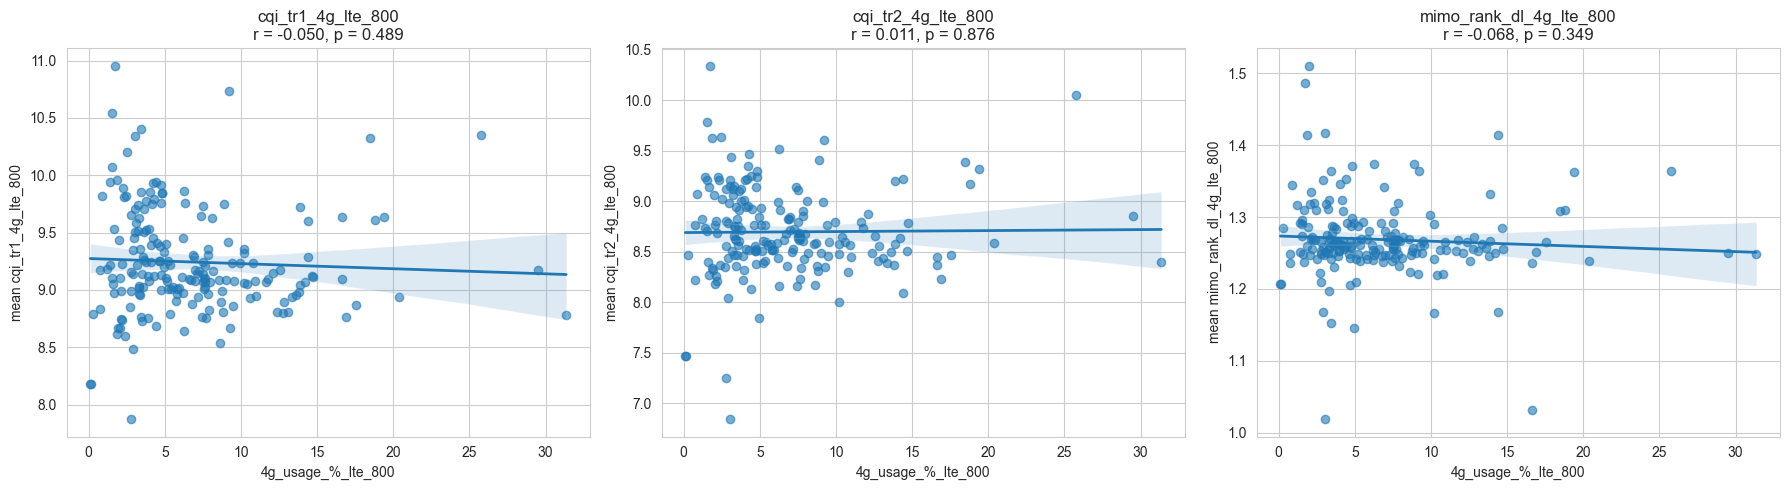

In [37]:
# DEFINITIONS
SOURCE_METRIC = "4g_usage_%_lte_800"

TARGET_METRICS = [
    "cqi_tr1_4g_lte_800",
    "cqi_tr2_4g_lte_800",
    "mimo_rank_dl_4g_lte_800"
]

print("Analyzing impact of", SOURCE_METRIC, "on mean neighbor quality:", TARGET_METRICS)

# 1. KPI MEDIANS PER CELL - для каждой клетки: берёт ВСЕ её значения по времени и считает среднее
kpi_mean = df_kpi.groupby("cell")[ [SOURCE_METRIC] + TARGET_METRICS ].mean()

# 2. BUILD CELL-LEVEL DATASET
records = []
for _, row in neighbor_table.iterrows():
    cell = row["cell"]
    neighbors = row["neighbors"]
    # Проверка наличия KPI у source
    if cell not in kpi_mean.index:
        continue
    source_value = kpi_mean.loc[cell, SOURCE_METRIC]
    # KPI соседей
    neighbor_kpis = []
    for n in neighbors:
        if n in kpi_mean.index:
            neighbor_kpis.append(kpi_mean.loc[n, TARGET_METRICS])

    # если нет валидных соседей — пропускаем
    if len(neighbor_kpis) == 0:
        continue

    neighbor_df = pd.DataFrame(neighbor_kpis)

    record = {
        "cell": cell,
        "source_" + SOURCE_METRIC: source_value,
        "neighbor_count": len(neighbor_kpis)
    }

    # среднее качество соседей
    for metric in TARGET_METRICS:
        record["neighbor_mean_" + metric] = neighbor_df[metric].mean()

    records.append(record)

neighbor_analysis = pd.DataFrame(records)
print("Valid cells for analysis:", len(neighbor_analysis))


# 3. CORRELATION + PLOTS
print("\n" + "="*60)
print("CORRELATION: Source Load → Mean Neighbor Quality")
print("="*60)

# создаём 1 строку, 3 графика
fig, axes = plt.subplots(1, len(TARGET_METRICS), figsize=(18, 5))

for i, metric in enumerate(TARGET_METRICS):
    x = neighbor_analysis["source_" + SOURCE_METRIC]
    y = neighbor_analysis["neighbor_mean_" + metric]

    corr_val, p_val = pearsonr(x, y)
    print(f"{SOURCE_METRIC} → mean {metric}:")
    print(f"  Pearson r = {corr_val:.4f}, p-value = {p_val:.4f}")

    # PLOT
    sns.regplot(
        x=x,
        y=y,
        ax=axes[i],
        scatter_kws={"alpha": 0.6},
        line_kws={"linewidth": 2}
    )
    axes[i].set_xlabel(SOURCE_METRIC)
    axes[i].set_ylabel("mean " + metric)
    axes[i].set_title(
        f"{metric}\n"
        f"r = {corr_val:.3f}, p = {p_val:.3f}"
    )
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Nezistila sa žiadna významná korelácia medzi zaťažením bunky (4g_usage_%_lte_800) a kvalitou jej susedných buniek (CQI ani MIMO rank).

Hodnoty Pearsonovho koeficientu sú veľmi blízke nule a p-value je vysoké, čo znamená, že vzťah nie je štatisticky významný.

To naznačuje, že zaťaženie jednej bunky pravdepodobne nemá priamy vplyv na kvalitu jej susedov v tejto sieti.

# Vizualizacia -- Usage

BOXPLOT: Usage % → Mean Neighbor Quality


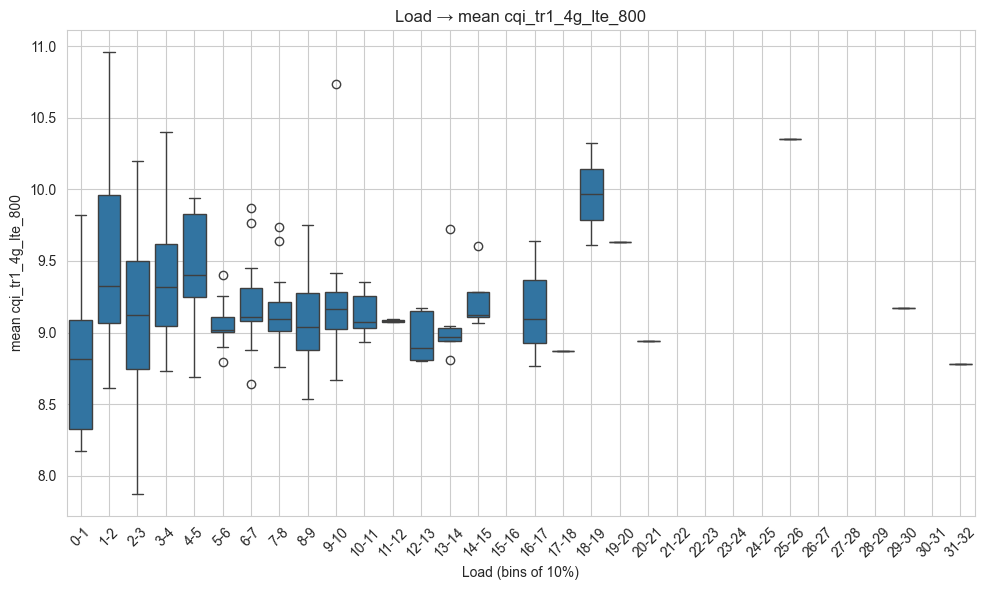

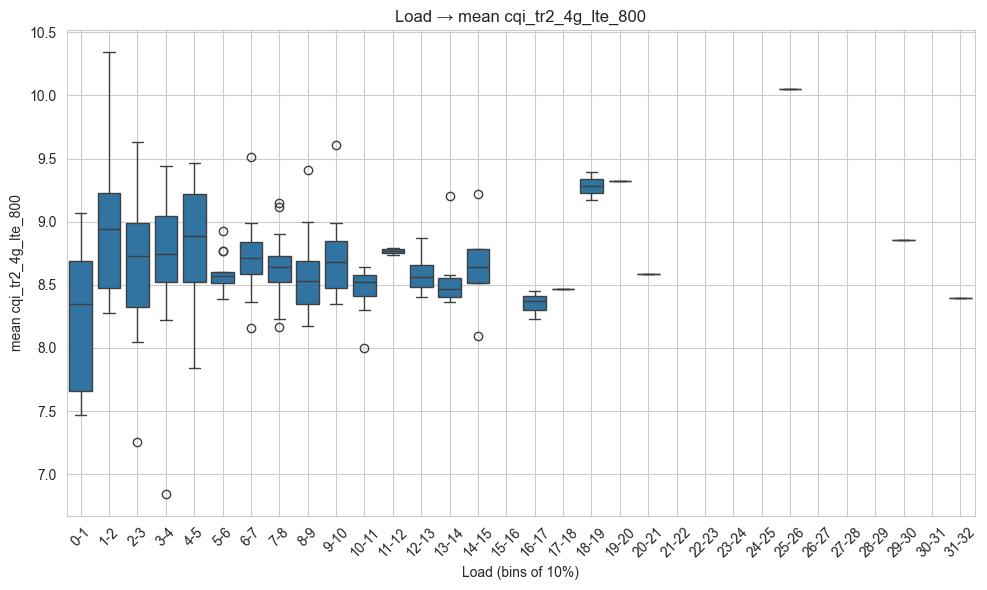

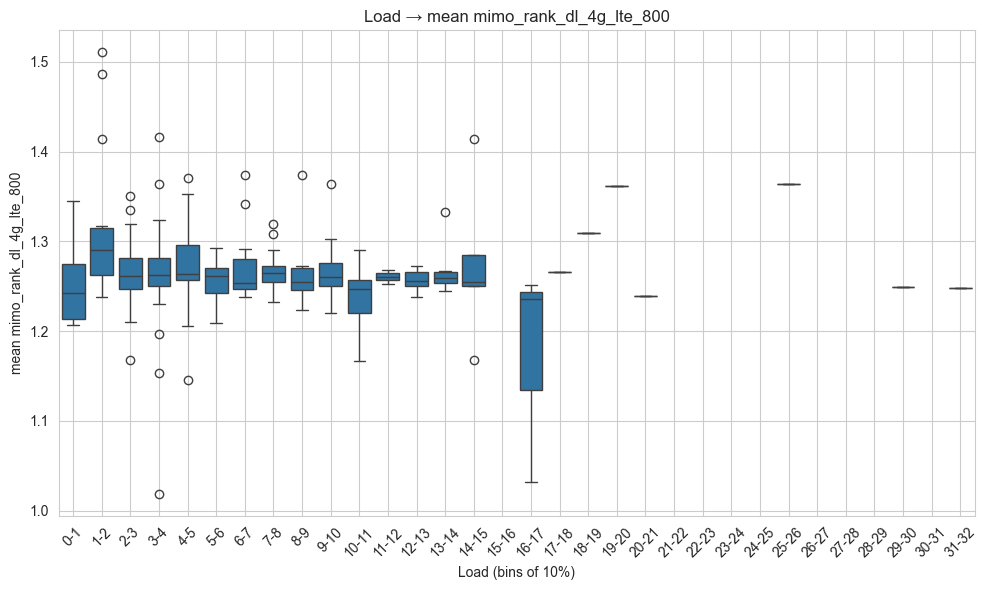

In [42]:
# BOXPLOT WITH FIXED BINS (LOAD-BASED)
print("BOXPLOT: Usage % → Mean Neighbor Quality")

# Ограничение по X (нагрузка в %)
max_load = 32
df_plot = neighbor_analysis[
    neighbor_analysis["source_4g_usage_%_lte_800"] <= max_load
].copy()

# создаём бины (например шаг = 10%)
bin_size = 1
bins = np.arange(0, max_load + bin_size, bin_size)

# labels вида "0-10", "10-20", ...
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]

df_plot["load_bin"] = pd.cut(
    df_plot["source_4g_usage_%_lte_800"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# PLOTS
for metric in TARGET_METRICS:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df_plot,
        x="load_bin",
        y="neighbor_mean_" + metric
    )
    plt.xlabel("Load (bins of 10%)")
    plt.ylabel("mean " + metric)
    plt.title(f"Load → mean {metric}")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Z grafov nevidno jasný trend, že by vyššia záťaž bunky viedla k horšej kvalite jej susedov.
Hodnoty CQI a MIMO sa medzi jednotlivými skupinami záťaže výrazne nemenia a majú podobný rozptyl.

# NEIGHBOR STRUCTURE CORRELATION ANALYSIS:
Neighbor Count → Mean Neighbor Quality

### Hypotéza: Ak má bunka veľa susedov (neighbor_count), potom priemerná kvalita jej susedných buniek (CQI, MIMO rank) je nižšia.

Analyzing impact of neighbor_count on mean neighbor quality: ['cqi_tr1_4g_lte_800', 'cqi_tr2_4g_lte_800', 'mimo_rank_dl_4g_lte_800']
Valid cells for analysis: 192

CORRELATION: Neighbor Count → Mean Neighbor Quality
neighbor_count → mean cqi_tr1_4g_lte_800:
  Pearson r = -0.3356, p-value = 0.0000
neighbor_count → mean cqi_tr2_4g_lte_800:
  Pearson r = -0.2058, p-value = 0.0042
neighbor_count → mean mimo_rank_dl_4g_lte_800:
  Pearson r = -0.2072, p-value = 0.0039


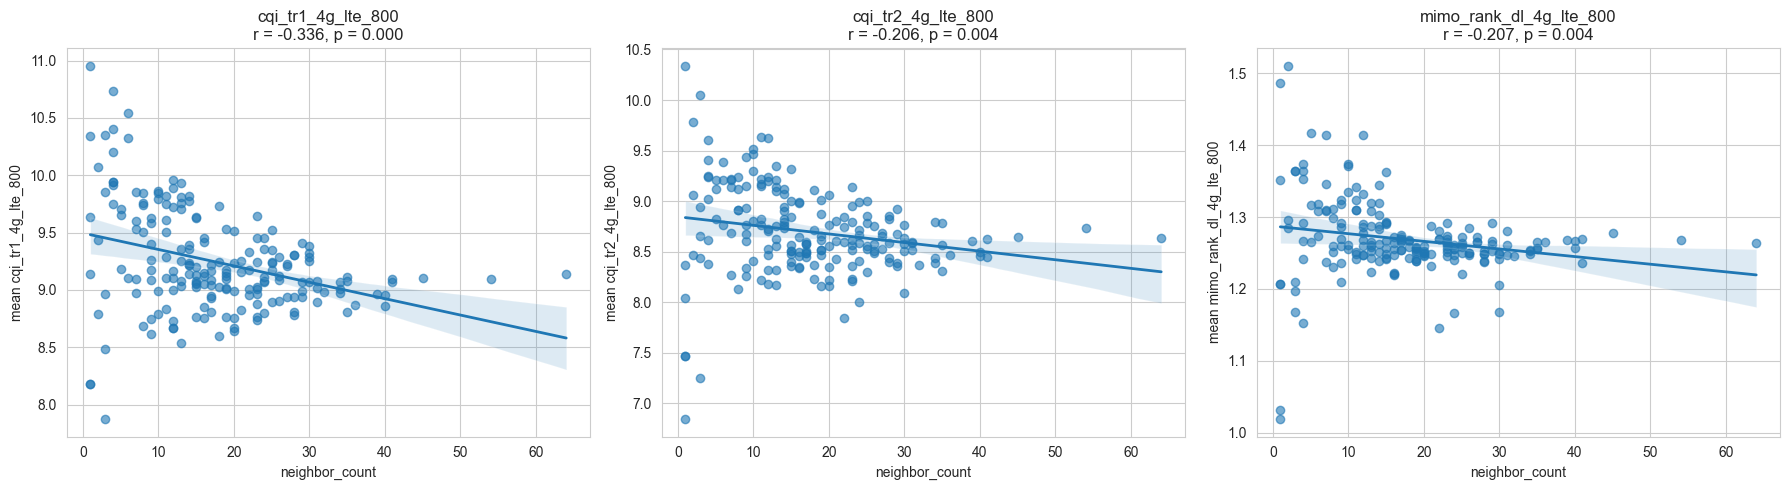

In [33]:
# DEFINITIONS
SOURCE_METRIC = "neighbor_count"

TARGET_METRICS = [
    "cqi_tr1_4g_lte_800",
    "cqi_tr2_4g_lte_800",
    "mimo_rank_dl_4g_lte_800"
]

print("Analyzing impact of", SOURCE_METRIC, "on mean neighbor quality:", TARGET_METRICS)


# 1. KPI MEAN PER CELL
kpi_mean = df_kpi.groupby("cell")[TARGET_METRICS].mean()


# 2. BUILD CELL-LEVEL DATASET
records = []

for _, row in neighbor_table.iterrows():
    cell = row["cell"]
    neighbors = row["neighbors"]
    neighbor_count = row["neighbor_count"]

    # KPI соседей
    neighbor_kpis = []
    for n in neighbors:
        if n in kpi_mean.index:
            neighbor_kpis.append(kpi_mean.loc[n, TARGET_METRICS])

    # если нет валидных соседей — пропускаем
    if len(neighbor_kpis) == 0:
        continue

    neighbor_df = pd.DataFrame(neighbor_kpis)

    record = {
        "cell": cell,
        "source_" + SOURCE_METRIC: neighbor_count,
        "neighbor_count": len(neighbor_kpis)
    }

    # среднее качество соседей
    for metric in TARGET_METRICS:
        record["neighbor_mean_" + metric] = neighbor_df[metric].mean()

    records.append(record)

neighbor_analysis = pd.DataFrame(records)

print("Valid cells for analysis:", len(neighbor_analysis))


# 3. CORRELATION + PLOTS
print("\n" + "="*60)
print("CORRELATION: Neighbor Count → Mean Neighbor Quality")
print("="*60)

# создаём 1 строку, 3 графика
fig, axes = plt.subplots(1, len(TARGET_METRICS), figsize=(18, 5))

for i, metric in enumerate(TARGET_METRICS):
    x = neighbor_analysis["source_" + SOURCE_METRIC]
    y = neighbor_analysis["neighbor_mean_" + metric]

    corr_val, p_val = pearsonr(x, y)
    print(f"{SOURCE_METRIC} → mean {metric}:")
    print(f"  Pearson r = {corr_val:.4f}, p-value = {p_val:.4f}")

    # PLOT
    sns.regplot(
        x=x,
        y=y,
        ax=axes[i],
        scatter_kws={"alpha": 0.6},
        line_kws={"linewidth": 2}
    )
    axes[i].set_xlabel(SOURCE_METRIC)
    axes[i].set_ylabel("mean " + metric)
    axes[i].set_title(
        f"{metric}\n"
        f"r = {corr_val:.3f}, p = {p_val:.3f}"
    )
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Existuje štatisticky významná negatívna korelácia medzi počtom susedov bunky a kvalitou jej susedných buniek (CQI aj MIMO rank).
To znamená, že bunky s väčším počtom susedov majú tendenciu mať horšiu priemernú kvalitu v okolí.
Výsledok naznačuje, že vyššia hustota susedov môže viesť k väčšiemu rušeniu (interference) v sieti.

# VISUALIZATION -- Neighbor Count

In [45]:
print(neighbor_analysis.columns)

Index(['cell', 'source_4g_usage_%_lte_800', 'neighbor_count',
       'neighbor_mean_cqi_tr1_4g_lte_800', 'neighbor_mean_cqi_tr2_4g_lte_800',
       'neighbor_mean_mimo_rank_dl_4g_lte_800'],
      dtype='object')


BOXPLOT: Neighbor Count → Mean Neighbor Quality


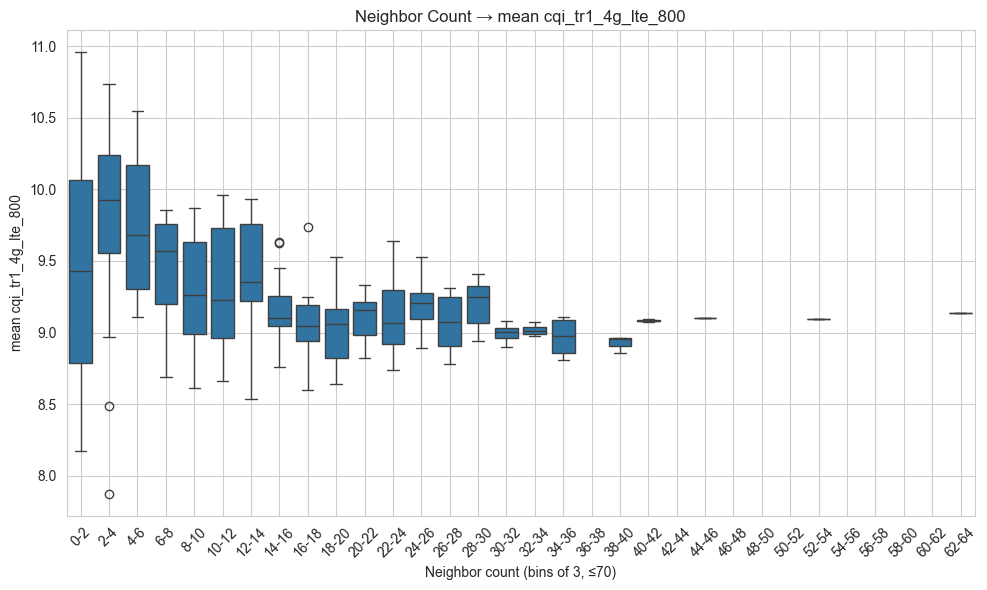

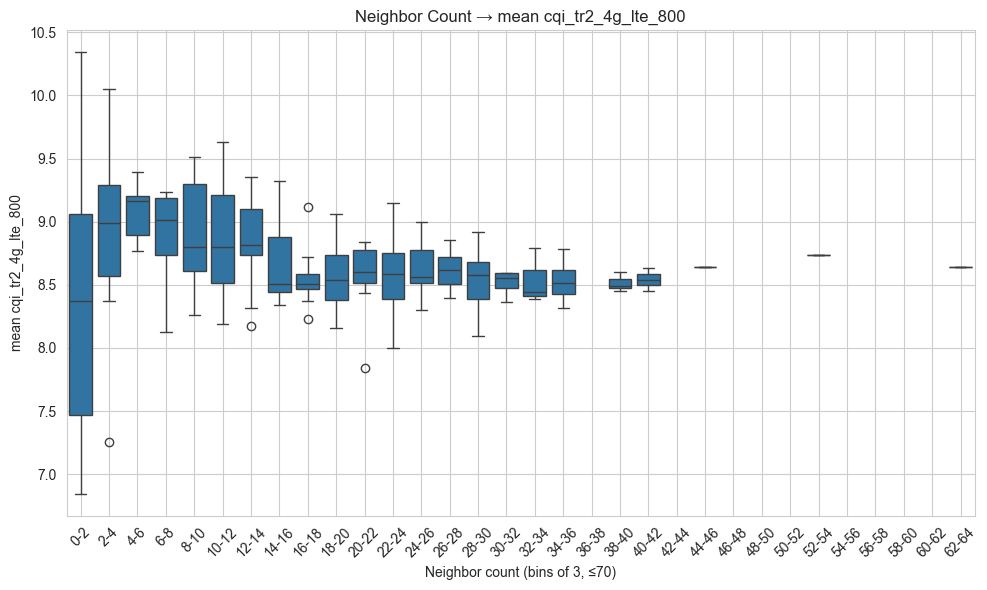

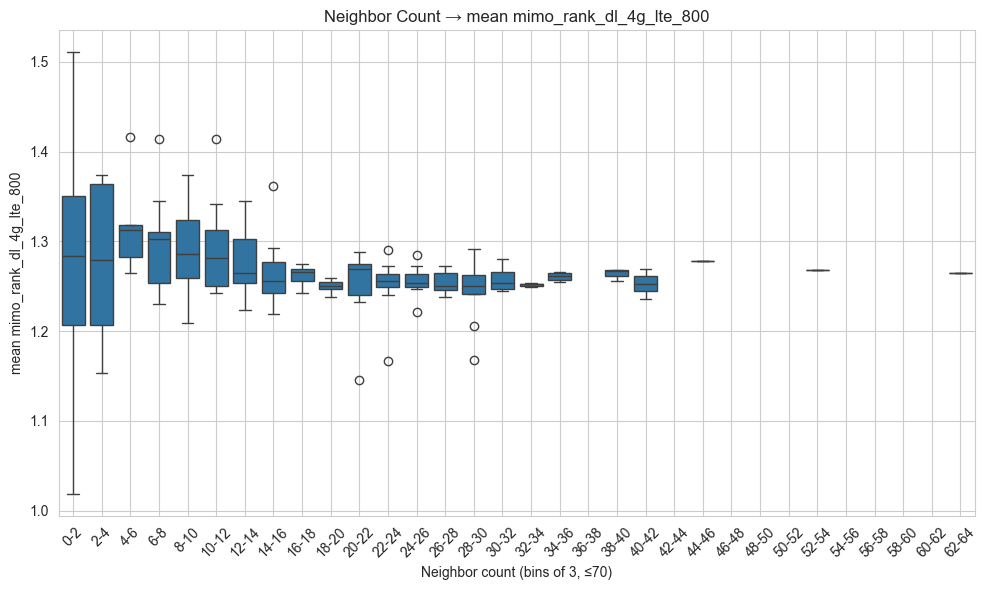

In [49]:
# BOXPLOT WITH FIXED BINS
print("BOXPLOT: Neighbor Count → Mean Neighbor Quality")

# Ограничение по X
max_neighbors = 64

df_plot = neighbor_analysis[
    neighbor_analysis["neighbor_count"] <= max_neighbors
].copy()

# создаём бины (шаг = 3)
bin_size = 2
bins = np.arange(0, max_neighbors + bin_size, bin_size)

# labels вида "0-3", "3-6", ...
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]

# используем именно neighbor_count
df_plot["neighbor_bin"] = pd.cut(
    df_plot["neighbor_count"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# PLOTS
for metric in TARGET_METRICS:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df_plot,
        x="neighbor_bin",
        y="neighbor_mean_" + metric
    )
    plt.xlabel("Neighbor count (bins of 3, ≤70)")
    plt.ylabel("mean " + metric)
    plt.title(f"Neighbor Count → mean {metric}")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Z grafov je vidieť mierny pokles kvality (CQI aj MIMO) so zvyšujúcim sa počtom susedov bunky.
To naznačuje, že bunky s veľkým počtom susedov môžu trpieť vyšším rušením (interference).